<a href="https://colab.research.google.com/github/neharam27/Deepfake-medical/blob/main/trial2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
STEP 0: Properly split data into Train/Val/Test with NO OVERLAP
This is the foundation to avoid leakage
"""

import os
import numpy as np
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import shutil

print("=" * 80)
print("STEP 0: PROPER DATA SPLITTING (NO LEAKAGE)")
print("=" * 80)

BASE_PATH = '/content/drive/MyDrive/Medical_Deepfake'
DATASET_PATH = f'{BASE_PATH}/datasets'
RAW_DATA = f'{DATASET_PATH}/pneumonia_raw'
IMG_SIZE = 64

# ============================================================================
# CONFIGURATION
# ============================================================================
print("""
DATA SPLIT STRATEGY:
  Train (60%): Only for GAN training
  Val (20%):   For detector training (real val + GAN-generated val fakes)
  Test (20%):  For evaluation (real test + GAN-generated test fakes)

This ensures ZERO overlap between datasets.
""")

# ============================================================================
# DOWNLOAD RAW DATA
# ============================================================================
print("\n[1/4] Downloading raw medical data...")

!pip install -q medmnist

from medmnist import PneumoniaMNIST

# Download dataset
train_dataset = PneumoniaMNIST(split='train', download=True, root=f'{DATASET_PATH}/raw')
test_dataset = PneumoniaMNIST(split='test', download=True, root=f'{DATASET_PATH}/raw')

print(f"✓ Downloaded {len(train_dataset)} train + {len(test_dataset)} test images")

# ============================================================================
# EXTRACT AND ORGANIZE RAW DATA
# ============================================================================
print("\n[2/4] Extracting and organizing raw data...")

def save_dataset(dataset, output_dir, prefix):
    """Save dataset images to directory"""
    os.makedirs(output_dir, exist_ok=True)

    for idx in tqdm(range(len(dataset)), desc=f"Saving {prefix}"):
        img, label = dataset[idx]
        img_np = np.array(img)

        # Handle shape
        if len(img_np.shape) == 3:
            if img_np.shape[0] == 3:
                img_np = cv2.cvtColor(img_np.transpose(1, 2, 0), cv2.COLOR_RGB2GRAY)
            else:
                img_np = img_np[0]

        # Resize to 64x64
        img_resized = cv2.resize(img_np, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)

        # Normalize to 0-255
        if img_resized.max() <= 1.0:
            img_resized = (img_resized * 255).astype(np.uint8)
        else:
            img_resized = img_resized.astype(np.uint8)

        # Save
        filepath = os.path.join(output_dir, f"{prefix}_{idx:05d}.png")
        cv2.imwrite(filepath, img_resized)

# Save raw data
save_dataset(train_dataset, f'{RAW_DATA}/train_raw', 'train')
save_dataset(test_dataset, f'{RAW_DATA}/test_raw', 'test')

print("✓ Raw data saved")

# ============================================================================
# COMBINE ALL DATA AND DO PROPER SPLIT
# ============================================================================
print("\n[3/4] Performing train/val/test split (60/20/20)...")

# Collect all images
all_images = []
all_image_paths = []

# From original train
for img_file in os.listdir(f'{RAW_DATA}/train_raw'):
    if img_file.endswith('.png'):
        all_image_paths.append(os.path.join(f'{RAW_DATA}/train_raw', img_file))
        all_images.append(img_file)

# From original test
for img_file in os.listdir(f'{RAW_DATA}/test_raw'):
    if img_file.endswith('.png'):
        all_image_paths.append(os.path.join(f'{RAW_DATA}/test_raw', img_file))
        all_images.append(img_file)

print(f"Total images: {len(all_images)}")

# Convert to numpy array for stratification
indices = np.arange(len(all_image_paths))

# Split: 60% train, 40% temp
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.4,
    random_state=42
)

# Split temp into val (50%) and test (50%) = 20% and 20% of total
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42
)

print(f"\n✓ Split completed:")
print(f"  Train: {len(train_idx)} images (60%)")
print(f"  Val:   {len(val_idx)} images (20%)")
print(f"  Test:  {len(test_idx)} images (20%)")

# ============================================================================
# CREATE SPLIT DIRECTORIES
# ============================================================================
print("\n[4/4] Creating split directories...")

split_dirs = {
    'train': f'{DATASET_PATH}/train',
    'val': f'{DATASET_PATH}/val',
    'test': f'{DATASET_PATH}/test'
}

for split_name, split_dir in split_dirs.items():
    os.makedirs(split_dir, exist_ok=True)

# Copy train files
for idx in tqdm(train_idx, desc="Copying train"):
    src = all_image_paths[idx]
    dst = os.path.join(split_dirs['train'], os.path.basename(src))
    shutil.copy(src, dst)

# Copy val files
for idx in tqdm(val_idx, desc="Copying val"):
    src = all_image_paths[idx]
    dst = os.path.join(split_dirs['val'], os.path.basename(src))
    shutil.copy(src, dst)

# Copy test files
for idx in tqdm(test_idx, desc="Copying test"):
    src = all_image_paths[idx]
    dst = os.path.join(split_dirs['test'], os.path.basename(src))
    shutil.copy(src, dst)

print("✓ Files copied to split directories")

# ============================================================================
# VERIFY NO OVERLAP
# ============================================================================
print("\n" + "=" * 80)
print("VERIFICATION - Confirming NO OVERLAP")
print("=" * 80)

train_files = set(os.listdir(split_dirs['train']))
val_files = set(os.listdir(split_dirs['val']))
test_files = set(os.listdir(split_dirs['test']))

overlap_train_val = train_files & val_files
overlap_train_test = train_files & test_files
overlap_val_test = val_files & test_files

print(f"\nTrain-Val overlap: {len(overlap_train_val)} (should be 0) ✓" if len(overlap_train_val) == 0 else f"\nTrain-Val overlap: {len(overlap_train_val)} ❌")
print(f"Train-Test overlap: {len(overlap_train_test)} (should be 0) ✓" if len(overlap_train_test) == 0 else f"Train-Test overlap: {len(overlap_train_test)} ❌")
print(f"Val-Test overlap: {len(overlap_val_test)} (should be 0) ✓" if len(overlap_val_test) == 0 else f"Val-Test overlap: {len(overlap_val_test)} ❌")

print("\n" + "=" * 80)
print("✅ STEP 0 COMPLETE - Clean train/val/test split")
print("=" * 80)
print(f"\nData structure:")
print(f"  Train: {split_dirs['train']}")
print(f"  Val:   {split_dirs['val']}")
print(f"  Test:  {split_dirs['test']}")

STEP 0: PROPER DATA SPLITTING (NO LEAKAGE)

DATA SPLIT STRATEGY:
  Train (60%): Only for GAN training
  Val (20%):   For detector training (real val + GAN-generated val fakes)
  Test (20%):  For evaluation (real test + GAN-generated test fakes)
  
This ensures ZERO overlap between datasets.


[1/4] Downloading raw medical data...
✓ Downloaded 4708 train + 624 test images

[2/4] Extracting and organizing raw data...


Saving test: 100%|██████████| 624/624 [00:00<00:00, 2751.71it/s]


✓ Raw data saved

[3/4] Performing train/val/test split (60/20/20)...
Total images: 5332

✓ Split completed:
  Train: 3199 images (60%)
  Val:   1066 images (20%)
  Test:  1067 images (20%)

[4/4] Creating split directories...


Copying test: 100%|██████████| 1067/1067 [00:00<00:00, 7911.35it/s]

✓ Files copied to split directories

VERIFICATION - Confirming NO OVERLAP

Train-Val overlap: 0 (should be 0) ✓
Train-Test overlap: 0 (should be 0) ✓
Val-Test overlap: 0 (should be 0) ✓

✅ STEP 0 COMPLETE - Clean train/val/test split

Data structure:
  Train: /content/drive/MyDrive/Medical_Deepfake/datasets/train
  Val:   /content/drive/MyDrive/Medical_Deepfake/datasets/val
  Test:  /content/drive/MyDrive/Medical_Deepfake/datasets/test


In [ ]:
"""
STEP 1: Train GAN ONLY on training split (60% of data)
GAN never sees val or test data
"""

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

print("=" * 80)
print("STEP 1: GAN TRAINING (TRAIN SPLIT ONLY - NO LEAKAGE)")
print("=" * 80)

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_PATH = '/content/drive/MyDrive/Medical_Deepfake'
DATASET_PATH = f'{BASE_PATH}/datasets'
CHECKPOINT_PATH = f'{BASE_PATH}/checkpoints'
RESULTS_PATH = f'{BASE_PATH}/results'

IMG_SIZE = 64
LATENT_DIM = 100
BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 0.0002
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

os.makedirs(CHECKPOINT_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Training on: {DATASET_PATH}/train (60% of data)")
print(f"GAN will NOT see val or test data")

# ============================================================================
# DATASET - ONLY FROM TRAIN SPLIT
# ============================================================================
class MedicalImageDataset(Dataset):

    def __init__(self, img_dir, img_size=64):
        self.img_dir = img_dir
        self.img_size = img_size
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.png')])
        print(f"Loaded {len(self.img_files)} images from {img_dir}")

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            return torch.zeros((1, self.img_size, self.img_size))

        img = img.astype(np.float32) / 255.0
        img = (img - 0.5) / 0.5

        img_tensor = torch.from_numpy(img).unsqueeze(0)
        return img_tensor

print("\n[1/3] Loading training split data...")
train_dataset = MedicalImageDataset(f'{DATASET_PATH}/train', IMG_SIZE)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
print(f"✓ Loaded {len(train_dataset)} training images")

# ============================================================================
# GAN ARCHITECTURE
# ============================================================================

class ImprovedGenerator(nn.Module):
    def __init__(self, latent_dim=100, img_size=64):
        super(ImprovedGenerator, self).__init__()
        self.latent_dim = latent_dim

        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)
        self.bn_fc = nn.BatchNorm1d(512 * 4 * 4)

        self.model = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = self.bn_fc(x)
        x = x.view(x.size(0), 512, 4, 4)
        x = self.model(x)
        return x


class ImprovedDiscriminator(nn.Module):
    def __init__(self, img_size=64):
        super(ImprovedDiscriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(256, 1)

    def forward(self, x):
        x = self.model(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

print("\n[2/3] Initializing GAN models...")

generator = ImprovedGenerator(latent_dim=LATENT_DIM, img_size=IMG_SIZE).to(DEVICE)
discriminator = ImprovedDiscriminator(img_size=IMG_SIZE).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()

optimizer_g = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

scheduler_g = optim.lr_scheduler.CosineAnnealingLR(optimizer_g, T_max=NUM_EPOCHS)
scheduler_d = optim.lr_scheduler.CosineAnnealingLR(optimizer_d, T_max=NUM_EPOCHS)

print("\n[3/3] Training GAN on training split...")

history = {'d_loss': [], 'g_loss': []}

for epoch in range(NUM_EPOCHS):
    d_losses = []
    g_losses = []

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for batch_idx, real_images in enumerate(progress_bar):
        real_images = real_images.to(DEVICE)
        batch_size = real_images.size(0)

        optimizer_d.zero_grad()
        d_real_output = discriminator(real_images)
        d_real_loss = criterion(d_real_output, torch.ones(batch_size, 1).to(DEVICE))

        z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake_images = generator(z)
        d_fake_output = discriminator(fake_images.detach())
        d_fake_loss = criterion(d_fake_output, torch.zeros(batch_size, 1).to(DEVICE))

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        optimizer_d.step()

        optimizer_g.zero_grad()
        z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake_images = generator(z)
        d_fake_output = discriminator(fake_images)
        g_loss = criterion(d_fake_output, torch.ones(batch_size, 1).to(DEVICE))
        g_loss.backward()
        optimizer_g.step()

        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())

    scheduler_g.step()
    scheduler_d.step()

# ============================================================================
# SAVE FINAL MODELS (ONLY FIXED PART)
# ============================================================================
NEW_MODEL_PATH = f'{BASE_PATH}/trained_generators'
os.makedirs(NEW_MODEL_PATH, exist_ok=True)

GEN_SAVE_PATH = f'{NEW_MODEL_PATH}/generator_train_only.pt'
DISC_SAVE_PATH = f'{NEW_MODEL_PATH}/discriminator_train_only.pt'

torch.save(generator.state_dict(), GEN_SAVE_PATH)
torch.save(discriminator.state_dict(), DISC_SAVE_PATH)

print("✓ Generator saved at:")
print(GEN_SAVE_PATH)

print("✓ Discriminator saved at:")
print(DISC_SAVE_PATH)

print("\nSTEP 1 COMPLETE")

STEP 1: GAN TRAINING (TRAIN SPLIT ONLY - NO LEAKAGE)
Device: cuda
Training on: /content/drive/MyDrive/Medical_Deepfake/datasets/train (60% of data)
GAN will NOT see val or test data

[1/3] Loading training split data...
Loaded 3199 images from /content/drive/MyDrive/Medical_Deepfake/datasets/train
✓ Loaded 3199 training images

[2/3] Initializing GAN models...

[3/3] Training GAN on training split...


Epoch 100/100: 100%|██████████| 100/100 [00:03<00:00, 27.78it/s]

✓ Generator saved at:
/content/drive/MyDrive/Medical_Deepfake/trained_generators/generator_train_only.pt
✓ Discriminator saved at:
/content/drive/MyDrive/Medical_Deepfake/trained_generators/discriminator_train_only.pt

STEP 1 COMPLETE


STEP 2: GENERATE VALIDATION & TEST FAKES (SEPARATE GENERATION)
Device: cuda

[1/3] Loading pre-trained generator...
✓ Generator loaded

[2/3] Generating validation fakes...
  Target: 1066 fake images


100%|██████████| 34/34 [00:00<00:00, 57.65it/s]


✓ Generated 1066 validation fakes

[3/3] Generating test fakes...
  Target: 1067 fake images


100%|██████████| 34/34 [00:00<00:00, 67.21it/s]


✓ Generated 1067 test fakes

Generating visualizations...


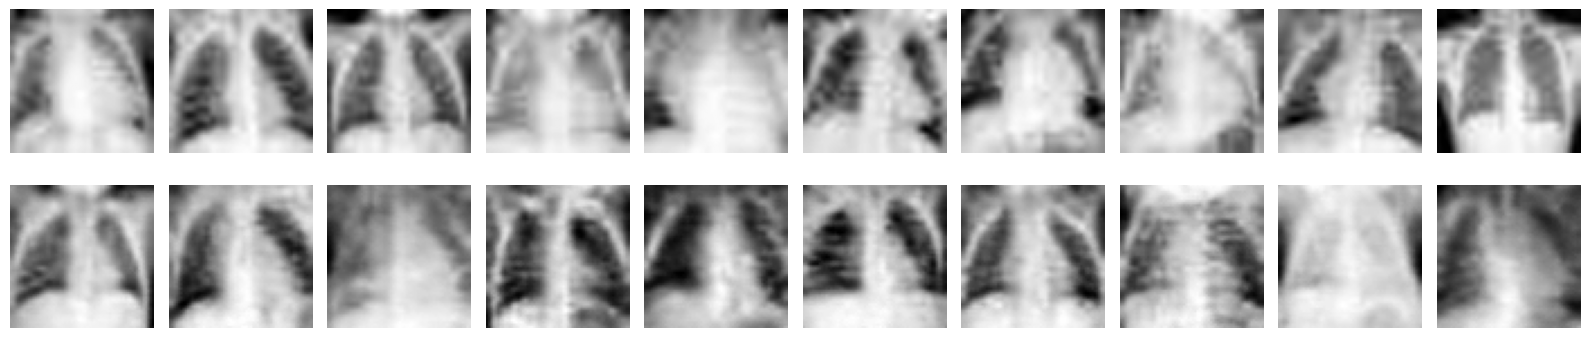


STEP 2 COMPLETE


In [ ]:
"""
STEP 2: Generate fake images for Val and Test separately
Val fakes for detector training, Test fakes for evaluation only
"""

import os
import torch
import torch.nn as nn
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

print("=" * 80)
print("STEP 2: GENERATE VALIDATION & TEST FAKES (SEPARATE GENERATION)")
print("=" * 80)

BASE_PATH = '/content/drive/MyDrive/Medical_Deepfake'
DATASET_PATH = f'{BASE_PATH}/datasets'
RESULTS_PATH = f'{BASE_PATH}/results'
FAKES_PATH = f'{BASE_PATH}/generated_fakes'

# 🔥 LOAD FROM NEW SAVE LOCATION
GEN_PATH = f'{BASE_PATH}/trained_generators/generator_train_only.pt'

IMG_SIZE = 64
LATENT_DIM = 100
BATCH_SIZE = 32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

os.makedirs(f'{FAKES_PATH}/val', exist_ok=True)
os.makedirs(f'{FAKES_PATH}/test', exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print(f"Device: {DEVICE}")

# ============================================================================
# LOAD TRAINED GENERATOR
# ============================================================================
print("\n[1/3] Loading pre-trained generator...")

class ImprovedGenerator(nn.Module):
    def __init__(self, latent_dim=100, img_size=64):
        super(ImprovedGenerator, self).__init__()

        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)
        self.bn_fc = nn.BatchNorm1d(512 * 4 * 4)

        self.model = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = self.bn_fc(x)
        x = x.view(x.size(0), 512, 4, 4)
        return self.model(x)

generator = ImprovedGenerator(latent_dim=LATENT_DIM, img_size=IMG_SIZE).to(DEVICE)

# 🔥 CHECK MODEL EXISTS
if not os.path.exists(GEN_PATH):
    raise FileNotFoundError(f"""
Generator not found!

Expected at:
{GEN_PATH}

Please run STEP-1 fully to create this file.
""")

generator.load_state_dict(torch.load(GEN_PATH, map_location=DEVICE))
generator.eval()

print("✓ Generator loaded")

# ============================================================================
# GENERATE VAL FAKES
# ============================================================================
print("\n[2/3] Generating validation fakes...")

val_real_count = len(os.listdir(f'{DATASET_PATH}/val'))
print(f"  Target: {val_real_count} fake images")

with torch.no_grad():
    for i in tqdm(range(0, val_real_count, BATCH_SIZE)):
        batch_size = min(BATCH_SIZE, val_real_count - i)
        z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake_images = generator(z)

        for j in range(batch_size):
            img = fake_images[j].cpu().numpy().squeeze()
            img = ((img + 1) / 2 * 255).astype(np.uint8)
            cv2.imwrite(f'{FAKES_PATH}/val/fake_val_{i+j:05d}.png', img)

print(f"✓ Generated {val_real_count} validation fakes")

# ============================================================================
# GENERATE TEST FAKES
# ============================================================================
print("\n[3/3] Generating test fakes...")

test_real_count = len(os.listdir(f'{DATASET_PATH}/test'))
print(f"  Target: {test_real_count} fake images")

with torch.no_grad():
    for i in tqdm(range(0, test_real_count, BATCH_SIZE)):
        batch_size = min(BATCH_SIZE, test_real_count - i)
        z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake_images = generator(z)

        for j in range(batch_size):
            img = fake_images[j].cpu().numpy().squeeze()
            img = ((img + 1) / 2 * 255).astype(np.uint8)
            cv2.imwrite(f'{FAKES_PATH}/test/fake_test_{i+j:05d}.png', img)

print(f"✓ Generated {test_real_count} test fakes")

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 10, figsize=(16, 4))

real_val_files = sorted(os.listdir(f'{DATASET_PATH}/val'))[:10]
for idx, img_file in enumerate(real_val_files):
    ax = axes[0, idx]
    img = cv2.imread(f'{DATASET_PATH}/val/{img_file}', cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

fake_val_files = sorted(os.listdir(f'{FAKES_PATH}/val'))[:10]
for idx, img_file in enumerate(fake_val_files):
    ax = axes[1, idx]
    img = cv2.imread(f'{FAKES_PATH}/val/{img_file}', cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/03_real_vs_generated_fakes.png', dpi=150)
plt.show()

print("\nSTEP 2 COMPLETE")

In [ ]:
"""
STEP 3: Train detector ONLY on validation split
Real val images + Generated val fakes
Test data remains untouched for final evaluatiion
"""

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import torchvision.models as models

print("=" * 80)
print("STEP 3: DETECTOR TRAINING (VALIDATION SPLIT ONLY - NO LEAKAGE)")
print("=" * 80)

BASE_PATH = '/content/drive/MyDrive/Medical_Deepfake'
DATASET_PATH = f'{BASE_PATH}/datasets'
FAKES_PATH = f'{BASE_PATH}/generated_fakes'
MODELS_PATH = f'{BASE_PATH}/models'
RESULTS_PATH = f'{BASE_PATH}/results'

IMG_SIZE = 256
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

os.makedirs(MODELS_PATH, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"\nTraining data:")
print(f"  Real: {DATASET_PATH}/val")
print(f"  Fake: {FAKES_PATH}/val")
print(f"\nEvaluation will use TEST data (completely separate)")

# ============================================================================
# DATASET
# ============================================================================
class RealFakeDataset(Dataset):
    def __init__(self, real_dir, fake_dir, img_size=256):
        self.img_size = img_size
        self.images = []
        self.labels = []

        if os.path.exists(real_dir):
            for img_file in sorted(os.listdir(real_dir)):
                if img_file.endswith('.png'):
                    self.images.append(os.path.join(real_dir, img_file))
                    self.labels.append(0)

        if os.path.exists(fake_dir):
            for img_file in sorted(os.listdir(fake_dir)):
                if img_file.endswith('.png'):
                    self.images.append(os.path.join(fake_dir, img_file))
                    self.labels.append(1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            return torch.zeros((1,self.img_size,self.img_size)), self.labels[idx]

        img = cv2.resize(img,(self.img_size,self.img_size))
        img = img.astype(np.float32)/255.0
        return torch.from_numpy(img).unsqueeze(0), self.labels[idx]

print("\n[1/4] Loading validation data...")

dataset = RealFakeDataset(f'{DATASET_PATH}/val', f'{FAKES_PATH}/val', IMG_SIZE)

from sklearn.model_selection import train_test_split
indices=np.arange(len(dataset))
labels_arr=np.array(dataset.labels)

train_idx,internal_val_idx=train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels_arr
)

train_dataset=torch.utils.data.Subset(dataset,train_idx)
internal_val_dataset=torch.utils.data.Subset(dataset,internal_val_idx)

train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
internal_val_loader=DataLoader(internal_val_dataset,batch_size=BATCH_SIZE)

# ============================================================================
# MODEL
# ============================================================================
print("\n[2/4] Building detector model...")

class MedicalDeepfakeDetector(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        resnet=models.resnet18(pretrained=pretrained)
        resnet.conv1=nn.Conv2d(1,64,7,2,3,bias=False)
        self.backbone=nn.Sequential(*list(resnet.children())[:-1])
        self.classifier=nn.Sequential(
            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128,2)
        )
    def forward(self,x):
        f=self.backbone(x)
        f=torch.flatten(f,1)
        return self.classifier(f)

detector=MedicalDeepfakeDetector(pretrained=True).to(DEVICE)

criterion=nn.CrossEntropyLoss(weight=torch.tensor([1.0,1.2]).to(DEVICE))
optimizer=optim.Adam(detector.parameters(),lr=LEARNING_RATE,weight_decay=1e-5)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='max',factor=0.5,patience=3)

best_val_auc=0
patience_counter=0

print("\n[3/4] Training detector...")

for epoch in range(NUM_EPOCHS):
    detector.train()
    train_losses,train_preds,train_labels_list=[],[],[]

    progress_bar=tqdm(train_loader,desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")

    for images,labels in progress_bar:
        images,labels=images.to(DEVICE),labels.to(DEVICE)

        logits=detector(images)
        loss=criterion(logits,labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(detector.parameters(),max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())
        preds=torch.argmax(logits,dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_list.extend(labels.cpu().numpy())

        progress_bar.set_postfix({'loss':f'{np.mean(train_losses[-10:]):.4f}'})

    detector.eval()
    val_preds,val_labels_list,val_probs=[],[],[]

    with torch.no_grad():
        for images,labels in internal_val_loader:
            images,labels=images.to(DEVICE),labels.to(DEVICE)
            logits=detector(images)
            probs=torch.softmax(logits,dim=1)
            preds=torch.argmax(logits,dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())
            val_probs.extend(probs[:,1].cpu().numpy())

    val_auc=roc_auc_score(val_labels_list,val_probs)
    scheduler.step(val_auc)

    if val_auc>best_val_auc:
        best_val_auc=val_auc
        patience_counter=0
        torch.save(detector.state_dict(),f'{MODELS_PATH}/best_detector_leakage_free.pt')
    else:
        patience_counter+=1
        if patience_counter>=5:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("✓ Training complete")

torch.save(detector.state_dict(),f'{MODELS_PATH}/detector_final_leakage_free.pt')

print("\nSTEP 3 COMPLETE")
print(f"Best Validation AUC: {best_val_auc:.4f}")

STEP 3: DETECTOR TRAINING (VALIDATION SPLIT ONLY - NO LEAKAGE)
Device: cuda

Training data:
  Real: /content/drive/MyDrive/Medical_Deepfake/datasets/val
  Fake: /content/drive/MyDrive/Medical_Deepfake/generated_fakes/val

Evaluation will use TEST data (completely separate)

[1/4] Loading validation data...

[2/4] Building detector model...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]



[3/4] Training detector...


Epoch 50/50 [Train]: 100%|██████████| 54/54 [00:06<00:00,  8.20it/s, loss=0.0019]


✓ Training complete

STEP 3 COMPLETE
Best Validation AUC: 1.0000


In [ ]:
"""
STEP 4: Final evaluation on test set
This is the FIRST TIME detector sees test data
Completely unbiased evaluation
"""

import os
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import torchvision.models as models

print("=" * 80)
print("STEP 4: FINAL EVALUATION ON TEST SET (LEAKAGE-FREE)")
print("=" * 80)

BASE_PATH = '/content/drive/MyDrive/Medical_Deepfake'
DATASET_PATH = f'{BASE_PATH}/datasets'
FAKES_PATH = f'{BASE_PATH}/generated_fakes'
MODELS_PATH = f'{BASE_PATH}/models'
RESULTS_PATH = f'{BASE_PATH}/results'

IMG_SIZE = 256
BATCH_SIZE = 32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Device: {DEVICE}")

# ============================================================================
# LOAD DETECTOR
# ============================================================================
print("\n[1/4] Loading trained detector...")

class MedicalDeepfakeDetector(nn.Module):
    def __init__(self, pretrained=True):
        super(MedicalDeepfakeDetector, self).__init__()
        resnet = models.resnet18(pretrained=pretrained)
        resnet.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.classifier = nn.Sequential(
            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128,2)
        )
    def forward(self,x):
        f=self.backbone(x)
        f=torch.flatten(f,1)
        return self.classifier(f)

detector = MedicalDeepfakeDetector(pretrained=False).to(DEVICE)

# ✅ FIX 1 — LOAD STATE_DICT DIRECTLY
detector.load_state_dict(
    torch.load(f'{MODELS_PATH}/best_detector_leakage_free.pt', map_location=DEVICE)
)

detector.eval()
print("✓ Detector loaded")

# ============================================================================
# LOAD TEST DATA
# ============================================================================
print("\n[2/4] Loading test data...")

test_images=[]
test_labels=[]

for img_file in sorted(os.listdir(f'{DATASET_PATH}/test')):
    if img_file.endswith('.png'):
        img=cv2.imread(os.path.join(f'{DATASET_PATH}/test',img_file),cv2.IMREAD_GRAYSCALE)
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img=img.astype(np.float32)/255.0
        test_images.append(torch.from_numpy(img).unsqueeze(0))
        test_labels.append(0)

for img_file in sorted(os.listdir(f'{FAKES_PATH}/test')):
    if img_file.endswith('.png'):
        img=cv2.imread(os.path.join(f'{FAKES_PATH}/test',img_file),cv2.IMREAD_GRAYSCALE)
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img=img.astype(np.float32)/255.0
        test_images.append(torch.from_numpy(img).unsqueeze(0))
        test_labels.append(1)

# ============================================================================
# INFERENCE
# ============================================================================
print("\n[3/4] Running inference...")

all_preds=[]
all_probs=[]
all_labels=np.array(test_labels)

with torch.no_grad():
    for i in tqdm(range(0,len(test_images),BATCH_SIZE)):

        # ✅ FIX 2 — USE STACK INSTEAD OF CAT
        batch=torch.stack(test_images[i:i+BATCH_SIZE]).to(DEVICE)

        logits=detector(batch)
        probs=torch.softmax(logits,dim=1)
        preds=torch.argmax(logits,dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

all_preds=np.array(all_preds)
all_probs=np.array(all_probs)

# ============================================================================
# METRICS
# ============================================================================
print("\n[4/4] Calculating metrics...")

accuracy=accuracy_score(all_labels,all_preds)
precision=precision_score(all_labels,all_preds)
recall=recall_score(all_labels,all_preds)
f1=f1_score(all_labels,all_preds)
auc_score=roc_auc_score(all_labels,all_probs)

cm=confusion_matrix(all_labels,all_preds)
tn,fp,fn,tp=cm.ravel()

specificity=tn/(tn+fp)

print(classification_report(all_labels,all_preds,target_names=['Real','Fake']))

print("\nAccuracy:",accuracy)
print("Recall:",recall)
print("Specificity:",specificity)
print("AUC:",auc_score)

print("\nSTEP 4 COMPLETE")

STEP 4: FINAL EVALUATION ON TEST SET (LEAKAGE-FREE)
Device: cuda

[1/4] Loading trained detector...
✓ Detector loaded

[2/4] Loading test data...

[3/4] Running inference...


100%|██████████| 67/67 [00:02<00:00, 26.88it/s]


[4/4] Calculating metrics...
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      1067
        Fake       0.99      0.99      0.99      1067

    accuracy                           0.99      2134
   macro avg       0.99      0.99      0.99      2134
weighted avg       0.99      0.99      0.99      2134


Accuracy: 0.9906279287722587
Recall: 0.9925023430178069
Specificity: 0.9887535145267105
AUC: 0.9994905528292324

STEP 4 COMPLETE


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive/Medical_Deepfake'):
    for file in files:
        if file.endswith('.txt'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Medical_Deepfake/results/final_metrics.txt
/content/drive/MyDrive/Medical_Deepfake/results/final_metrics1.txt


In [ ]:
with open('/content/drive/MyDrive/Medical_Deepfake/results/final_metrics1.txt','r') as f:
    print(f.read())

Accuracy: 0.9906279287722587
Recall: 0.9925023430178069
Specificity: 0.9887535145267105
AUC: 0.9994905528292324



In [ ]:
with open('/content/drive/MyDrive/Medical_Deepfake/results/step0_split_info.txt','w') as f:
    f.write("STEP 0 COMPLETE\n")
    f.write("Train: 60%\nVal: 20%\nTest: 20%\n")
print("STEP 0 saved ✅")

STEP 0 saved ✅


In [ ]:
with open('/content/drive/MyDrive/Medical_Deepfake/results/step1_gan_summary.txt','w') as f:
    f.write(f"GAN trained for {NUM_EPOCHS} epochs\n")
    f.write("Generator saved at: trained_generators/\n")
print("STEP 1 summary saved ✅")

STEP 1 summary saved ✅


In [ ]:
with open('/content/drive/MyDrive/Medical_Deepfake/results/step2_fake_counts.txt','w') as f:
    f.write(f"Validation fakes generated: {val_real_count}\n")
    f.write(f"Test fakes generated: {test_real_count}\n")
print("STEP 2 saved ✅")

STEP 2 saved ✅


In [ ]:
with open('/content/drive/MyDrive/Medical_Deepfake/results/step3_detector_results.txt','w') as f:
    f.write(f"Best Validation AUC: {best_val_auc}\n")
print("STEP 3 saved ✅")

STEP 3 saved ✅


In [ ]:
with open('/content/drive/MyDrive/Medical_Deepfake/results/ALL_STEPS_SUMMARY.txt','w') as f:
    f.write("MEDICAL DEEPFAKE PIPELINE SUMMARY\n\n")
    f.write("STEP 0: Train/Val/Test Split Done\n")
    f.write(f"STEP 1: GAN trained for {NUM_EPOCHS} epochs\n")
    f.write(f"STEP 2: Val Fakes = {val_real_count}, Test Fakes = {test_real_count}\n")
    f.write(f"STEP 3: Best Val AUC = {best_val_auc}\n")
    f.write("\nFINAL TEST RESULTS\n")
    f.write(f"Accuracy: {accuracy}\n")
    f.write(f"Recall: {recall}\n")
    f.write(f"Specificity: {specificity}\n")
    f.write(f"AUC: {auc_score}\n")

print("ALL STEPS SUMMARY SAVED ✅")

ALL STEPS SUMMARY SAVED ✅
